In [2]:
# pip install gseapy

In [1]:
import pandas as pd
from gseapy.plot import gseaplot
import gseapy as gp
import numpy as np

In [120]:
dea_df = pd.read_csv("../results/de_genes_diss_bulk_polya+.csv")
dea_df = dea_df.rename(columns={"Unnamed: 0": "gene"})

In [121]:
dea_df["rank"] = -np.log10(dea_df["padj"])*dea_df["log2FoldChange"]

In [122]:
dea_df = dea_df.sort_values("rank", ascending=False).reset_index(drop=True)

In [123]:
dea_df.head()

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rank
0,CILP,1313.381456,3.212643,0.574656,5.590546,2.263561e-08,0.000697,10.141846
1,IGF2,4335.765303,4.004393,0.789254,5.073645,3.902665e-07,0.006007,8.895019
2,IGF2-AS,22.820741,5.325505,1.227796,4.337453,1.441436e-05,0.048618,6.993450
3,ENSG00000289074,32.629786,1.762493,0.408236,4.317336,1.579237e-05,0.048618,2.314505
4,LINC02940,67.294651,-1.616593,0.369531,-4.374711,1.215935e-05,0.046792,-2.149788


In [124]:
ranking = dea_df[["gene", "rank"]].set_index("gene", drop=True)

In [125]:
ranking.head()

,rank
gene,
CILP,10.141846
IGF2,8.895019
IGF2-AS,6.993450
ENSG00000289074,2.314505
LINC02940,-2.149788


In [126]:
# ranking["gene"].to_csv("../results/GOrilla_input_bulk_dea.csv", index=False)

In [127]:
adiposite_genes = pd.read_excel("../data/emont2022s1.xlsx", sheet_name="adipocyte markers", header=1)

In [128]:
adiposite_genes = list(adiposite_genes["Unnamed: 0"])

In [129]:
adiposite_genes[:5]

['NAV2', 'AC018616.1', 'FABP4', 'MAPK10', 'ITLN1']

In [130]:
shared_genes = list(set(ranking.index)&set(adiposite_genes))

In [131]:
dea_df[dea_df["gene"].isin(shared_genes)]

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,rank
5,C9orf72,669.454321,-1.49056,0.333099,-4.474831,0.000008,0.035439,-2.16208


In [132]:
len(adiposite_genes)

2586

In [133]:
set(adiposite_genes)&set(dea_df["gene"])

{'C9orf72'}

In [143]:
pre_res = gp.prerank(
    rnk=ranking,
    gene_sets={"my_set": adiposite_genes},
    seed=2,
    min_size=1,
    max_size=1000,
    verbose=True
)

2025-04-21 16:34:05,929 [INFO] Parsing data files for GSEA.............................
2025-04-21 16:34:05,934 [INFO] 0001 gene_sets have been filtered out when max_size=1000 and min_size=1
2025-04-21 16:34:05,935 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

2025-04-21 16:34:05,935 [ERROR] The first entry of your gene_sets (gmt) look like this : { my_set: [NAV2, AC018616.1, FABP4, MAPK10, ITLN1, B2M, TIMP1, PDK4, BOC, MKX, ABCA8, ARHGAP24, TSHZ2, LHFPL6, NWD2, MIR100HG, ENOX1, LRP1B, C7, C1QB, ALDH1A1, KCNIP2-AS1, TXNIP, EPB41L3, AC012349.1, RSPO3, CIDEA, C3, TM4SF1, C1QA, MT-ND3, RHOBTB3, NR2F1, AL109930.1, ADH1B, MEIS1, MT-CO3, RORB, AC006387.1, PKHD1L1, LINC00968, UNC5C, FAM13A, LINC01725, MARCO, AL359220.1, RNASE1, GLRX, HLA-DRA, ANO6, FAM155A, SELENOP, AC104827.1, RARRES1, TMEM132

LookupError: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.


In [135]:
pre_res.results

{'my_set': {'name': 'prerank',
  'es': -0.3315121179675678,
  'nes': -0.7731594314752304,
  'pval': 0.6823204419889503,
  'fdr': 0.6823204419889503,
  'fwerp': 0.6823204419889503,
  'tag %': '5/14',
  'gene %': '27.70%',
  'lead_genes': 'PCSK6;MME;ACADL;MKX;TMEFF2',
  'matched_genes': 'C1QB;C1QA;IRF8;HLA-DRA;ANKRD36C;LTBP1;RNF217-AS1;CTH;CRNDE;TMEFF2;MKX;ACADL;MME;PCSK6',
  'hits': [21, 38, 52, 60, 74, 78, 79, 84, 96, 108, 112, 116, 131, 138],
  'RES': [-0.007462686567164179,
   -0.014925373134328358,
   -0.022388059701492536,
   -0.029850746268656716,
   -0.03731343283582089,
   -0.04477611940298507,
   -0.05223880597014925,
   -0.05970149253731343,
   -0.06716417910447761,
   -0.07462686567164178,
   -0.08208955223880596,
   -0.08955223880597013,
   -0.0970149253731343,
   -0.10447761194029848,
   -0.11194029850746265,
   -0.11940298507462682,
   -0.126865671641791,
   -0.13432835820895517,
   -0.14179104477611934,
   -0.1492537313432835,
   -0.1567164179104477,
   -0.089008126786845

In [136]:
out = []
for term in list(pre_res.results):
    out.append(
        [
            term,
            pre_res.results[term]["fdr"],
            pre_res.results[term]["es"],
            pre_res.results[term]["nes"],
        ]
    )

out_df = pd.DataFrame(
    out,
    columns=["Term", "fdr", "es", "nes"],
).sort_values(
    "fdr",
).reset_index(
    drop=True
)

out_df

,Term,fdr,es,nes
0,my_set,0.68232,-0.331512,-0.773159


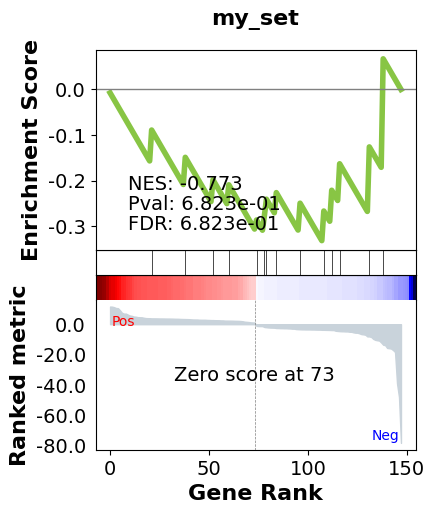

In [137]:
terms = pre_res.res2d.Term
axs = pre_res.plot(terms=out_df["Term"].iloc[0])

In [119]:
# figname="../results/figures/gsea_plot_bulk_rrna-"
# axs.savefig(figname + ".png", bbox_inches="tight")
# axs.savefig(figname + ".pdf", bbox_inches="tight")